In [10]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install missingno
!pip install notebook

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.2/101.7 MB 5.3 MB/s eta 0:00:20
   ---------------------------------------- 0.5/101.7 MB 5.6 MB/s eta 0:00:19
   ---------------------------------------- 0.8/101.7 MB 6.4 MB/s eta 0:00:16
   ---------------------------------------- 1.0/101.7 MB 5.7 MB/s eta 0:00:18
    --------------------------------------- 1.3/101.7 MB 6.4 MB/s eta 0:00:16
    --------------------------------------- 1.5/101.7 MB 5.5 MB/s eta 0:00:19
    --------------------------------------- 1.7/101.7 MB 5.7 MB/s eta 0:00:18
    --------------------------------------- 2.1/101.7 MB 5.8 MB/s eta 0:00:18
    --------------------------------------- 2.3/101.7 MB 5.5 MB/s eta 0:00:18
    --------------------------------------- 2.4/101.7 MB 5.8 MB/s eta 0:00:18
   - -------------------------------------- 2.6/101.7 MB 5.4 MB/s eta 0:00:19
 

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [12]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test (3).csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (8523, 12)
Test Shape: (5681, 11)


In [13]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [15]:
train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [16]:
train.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

<Axes: >

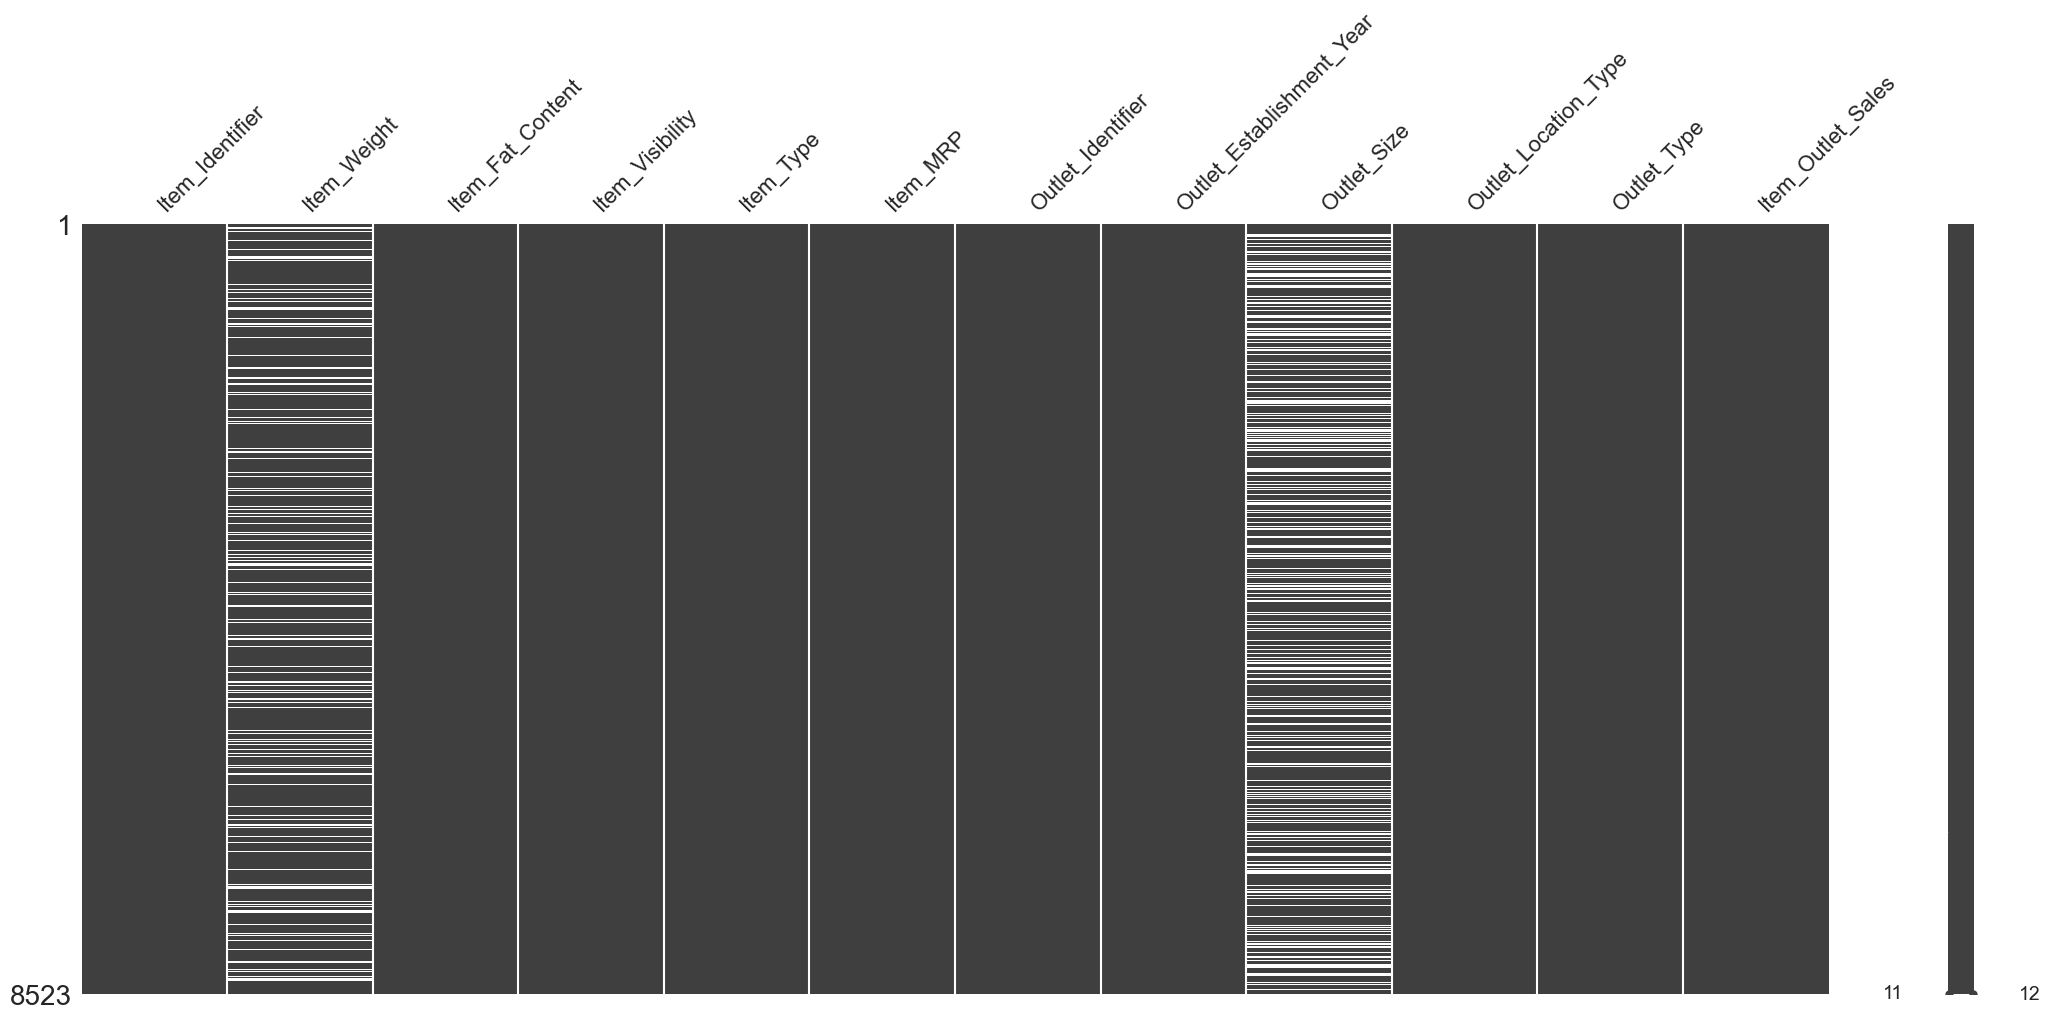

In [17]:
import missingno as msno
msno.matrix(train)

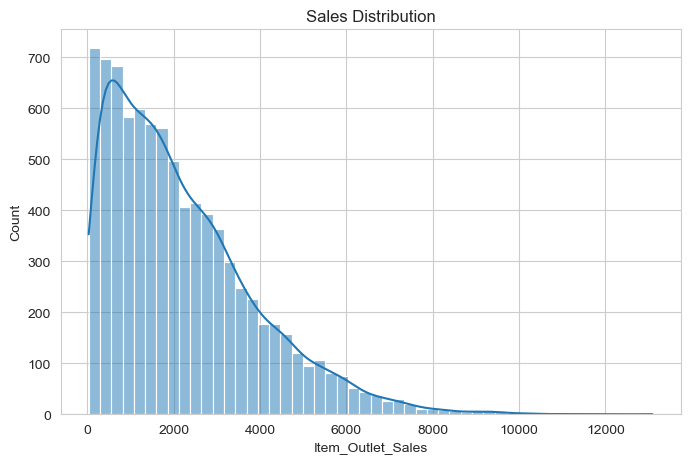

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(train['Item_Outlet_Sales'], bins=50, kde=True)
plt.title("Sales Distribution")
plt.show()

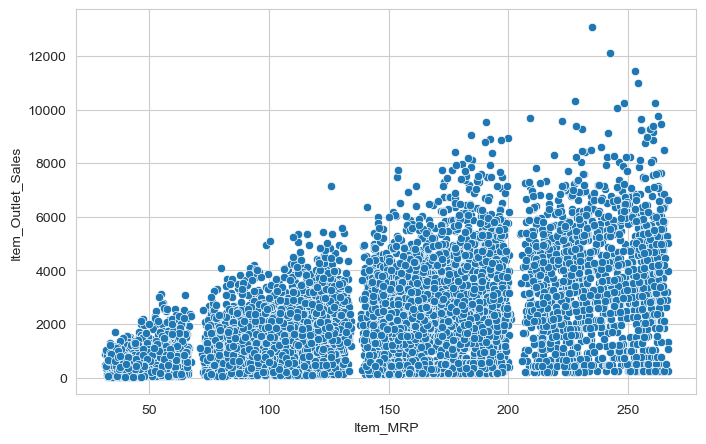

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=train)
plt.show()

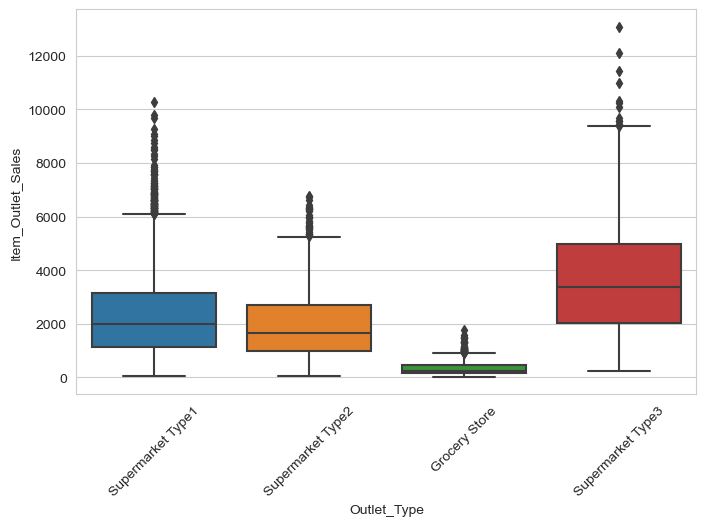

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=train)
plt.xticks(rotation=45)
plt.show()

In [21]:
train['source'] = 'train'
test['source'] = 'test'
test['Item_Outlet_Sales'] = 0

data = pd.concat([train, test], ignore_index=True)

In [22]:
data['Item_Fat_Content'] = data['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

In [23]:
data['Item_Weight'] = data.groupby('Item_Identifier')['Item_Weight']\
                          .transform(lambda x: x.fillna(x.mean()))

In [24]:
data['Outlet_Size'] = data['Outlet_Size'].fillna(data['Outlet_Size'].mode()[0])

In [25]:
data['Item_Visibility'] = data['Item_Visibility'].replace(
    0, data['Item_Visibility'].mean()
)

In [26]:
data['Item_Type_Combined'] = data['Item_Identifier'].apply(lambda x: x[:2])

data['Item_Type_Combined'] = data['Item_Type_Combined'].map({
    'FD': 'Food',
    'NC': 'Non-Consumable',
    'DR': 'Drinks'
})

In [27]:
data['Outlet_Years'] = 2024 - data['Outlet_Establishment_Year']

In [28]:
le = LabelEncoder()

categorical_cols = data.select_dtypes(include='object').columns

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [29]:
train = data[data['source'] == 1]
test = data[data['source'] == 0]

train.drop(['source'], axis=1, inplace=True)
test.drop(['source', 'Item_Outlet_Sales'], axis=1, inplace=True)

In [30]:
X = train.drop(['Item_Outlet_Sales'], axis=1)
y = train['Item_Outlet_Sales']

In [31]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_valid)
rmse_lr = np.sqrt(mean_squared_error(y_valid, pred_lr))

print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 1136.1705209327376


In [34]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_valid)
rmse_rf = np.sqrt(mean_squared_error(y_valid, pred_rf))

print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 1075.1711848861328


In [35]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_valid)
rmse_xgb = np.sqrt(mean_squared_error(y_valid, pred_xgb))

print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 1101.960602671374


In [36]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb, X, y,
    scoring='neg_root_mean_squared_error',
    cv=kf
)

print("CV RMSE:", -cv_scores.mean())

CV RMSE: 1147.5142336319273


In [37]:
params = {
    'max_depth': [4,6,8],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [300,500]
}

grid = GridSearchCV(
    XGBRegressor(),
    params,
    scoring='neg_root_mean_squared_error',
    cv=3
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300}


In [38]:
xgb.fit(X, y)
final_predictions = xgb.predict(test)

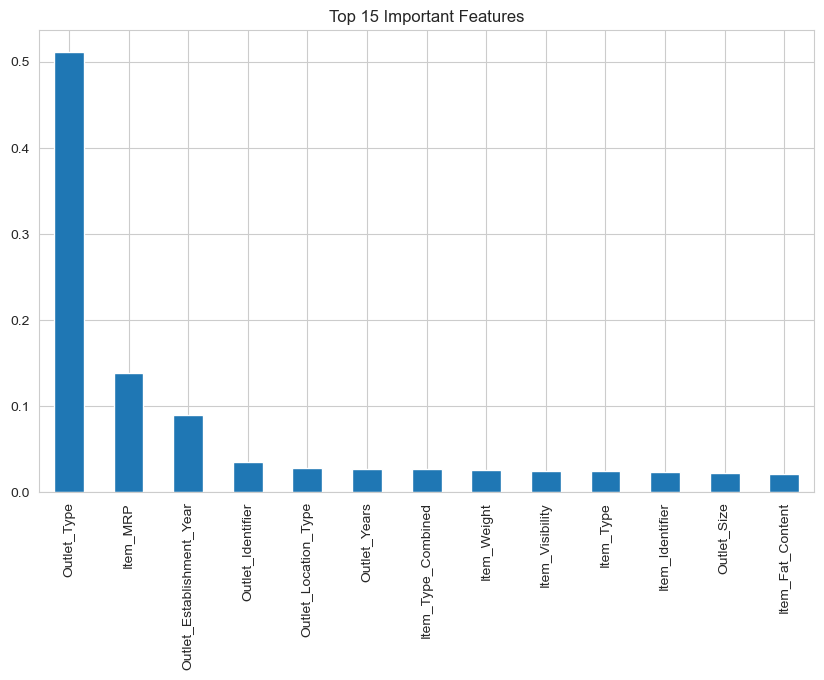

In [39]:
importances = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(15).plot(kind='bar')
plt.title("Top 15 Important Features")
plt.show()

In [40]:
submission = pd.DataFrame({
    'Item_Identifier': test['Item_Identifier'],
    'Outlet_Identifier': test['Outlet_Identifier'],
    'Item_Outlet_Sales': final_predictions
})

submission.to_csv("submission.csv", index=False)